In [172]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn import metrics
from sklearn.preprocessing import PolynomialFeatures
from sklearn.feature_selection import SelectFromModel, SelectKBest, r_regression, f_regression , mutual_info_regression
from sklearn.preprocessing import LabelEncoder
from warnings import filterwarnings
filterwarnings("ignore")

In [173]:
data = pd.read_csv('cardata.csv')

In [174]:
df=pd.DataFrame(data)
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [175]:
df.shape

(301, 9)

In [176]:
df.drop(['Car_Name'],axis = 1, inplace = True)
df.head()

,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [177]:
#chechikng for nulls :
df.isnull().sum()

Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [178]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Year           301 non-null    int64  
 1   Selling_Price  301 non-null    float64
 2   Present_Price  301 non-null    float64
 3   Kms_Driven     301 non-null    int64  
 4   Fuel_Type      301 non-null    object 
 5   Seller_Type    301 non-null    object 
 6   Transmission   301 non-null    object 
 7   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(3)
memory usage: 18.9+ KB


In [179]:
#Checking for duplicated rows :
print(len(df[df.duplicated()]))
df[df.duplicated()]

2


,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
17,2016,7.75,10.79,43000,Diesel,Dealer,Manual,0
93,2015,23.00,30.61,40000,Diesel,Dealer,Automatic,0


In [180]:
#Drop duplicated values :
df1 = df.copy()
df1 = df1.drop_duplicates().reset_index(drop=True)
df1

,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...
294,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
295,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
296,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
297,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [181]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Year           299 non-null    int64  
 1   Selling_Price  299 non-null    float64
 2   Present_Price  299 non-null    float64
 3   Kms_Driven     299 non-null    int64  
 4   Fuel_Type      299 non-null    object 
 5   Seller_Type    299 non-null    object 
 6   Transmission   299 non-null    object 
 7   Owner          299 non-null    int64  
dtypes: float64(2), int64(3), object(3)
memory usage: 18.8+ KB


In [182]:
#Separating numerical and categorical columns :
df_obj = df.select_dtypes(['object'])
df_num = df.select_dtypes(include=['int64','float64'])
df_num.head()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
0,2014,3.35,5.59,27000,0
1,2013,4.75,9.54,43000,0
2,2017,7.25,9.85,6900,0
3,2011,2.85,4.15,5200,0
4,2014,4.60,6.87,42450,0


In [183]:
#Basic information about our data set :

#Using display so we can have the information of our numerical and categorical columns at the same time
display(df_num.describe().T)
df_obj.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,301.0,2013.627907,2.891554,2003.00,2012.0,2014.0,2016.0,2018.0
Selling_Price,301.0,4.661296,5.082812,0.10,0.9,3.6,6.0,35.0
Present_Price,301.0,7.628472,8.644115,0.32,1.2,6.4,9.9,92.6
Kms_Driven,301.0,36947.205980,38886.883882,500.00,15000.0,32000.0,48767.0,500000.0
Owner,301.0,0.043189,0.247915,0.00,0.0,0.0,0.0,3.0


,count,unique,top,freq
Fuel_Type,301,3,Petrol,239
Seller_Type,301,2,Dealer,195
Transmission,301,2,Manual,261


In [184]:
#Changing "Year" feature to "Age" :
df2 = df1.copy()
#So now cars from the latest year would have the value of '1' for their age
df2['Age'] = (df.Year.max()+1) - df.Year

#Droping unnecessary column al relocating "Age" column in data set
df2.drop(['Year'], axis='columns',inplace = True)
df2

,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Age
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,5
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,6
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,2
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,8
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,5
...,...,...,...,...,...,...,...,...
294,9.50,11.60,33988,Diesel,Dealer,Manual,0,5
295,4.00,5.90,60000,Petrol,Dealer,Manual,0,4
296,3.35,11.00,87934,Petrol,Dealer,Manual,0,3
297,11.50,12.50,9000,Diesel,Dealer,Manual,0,4


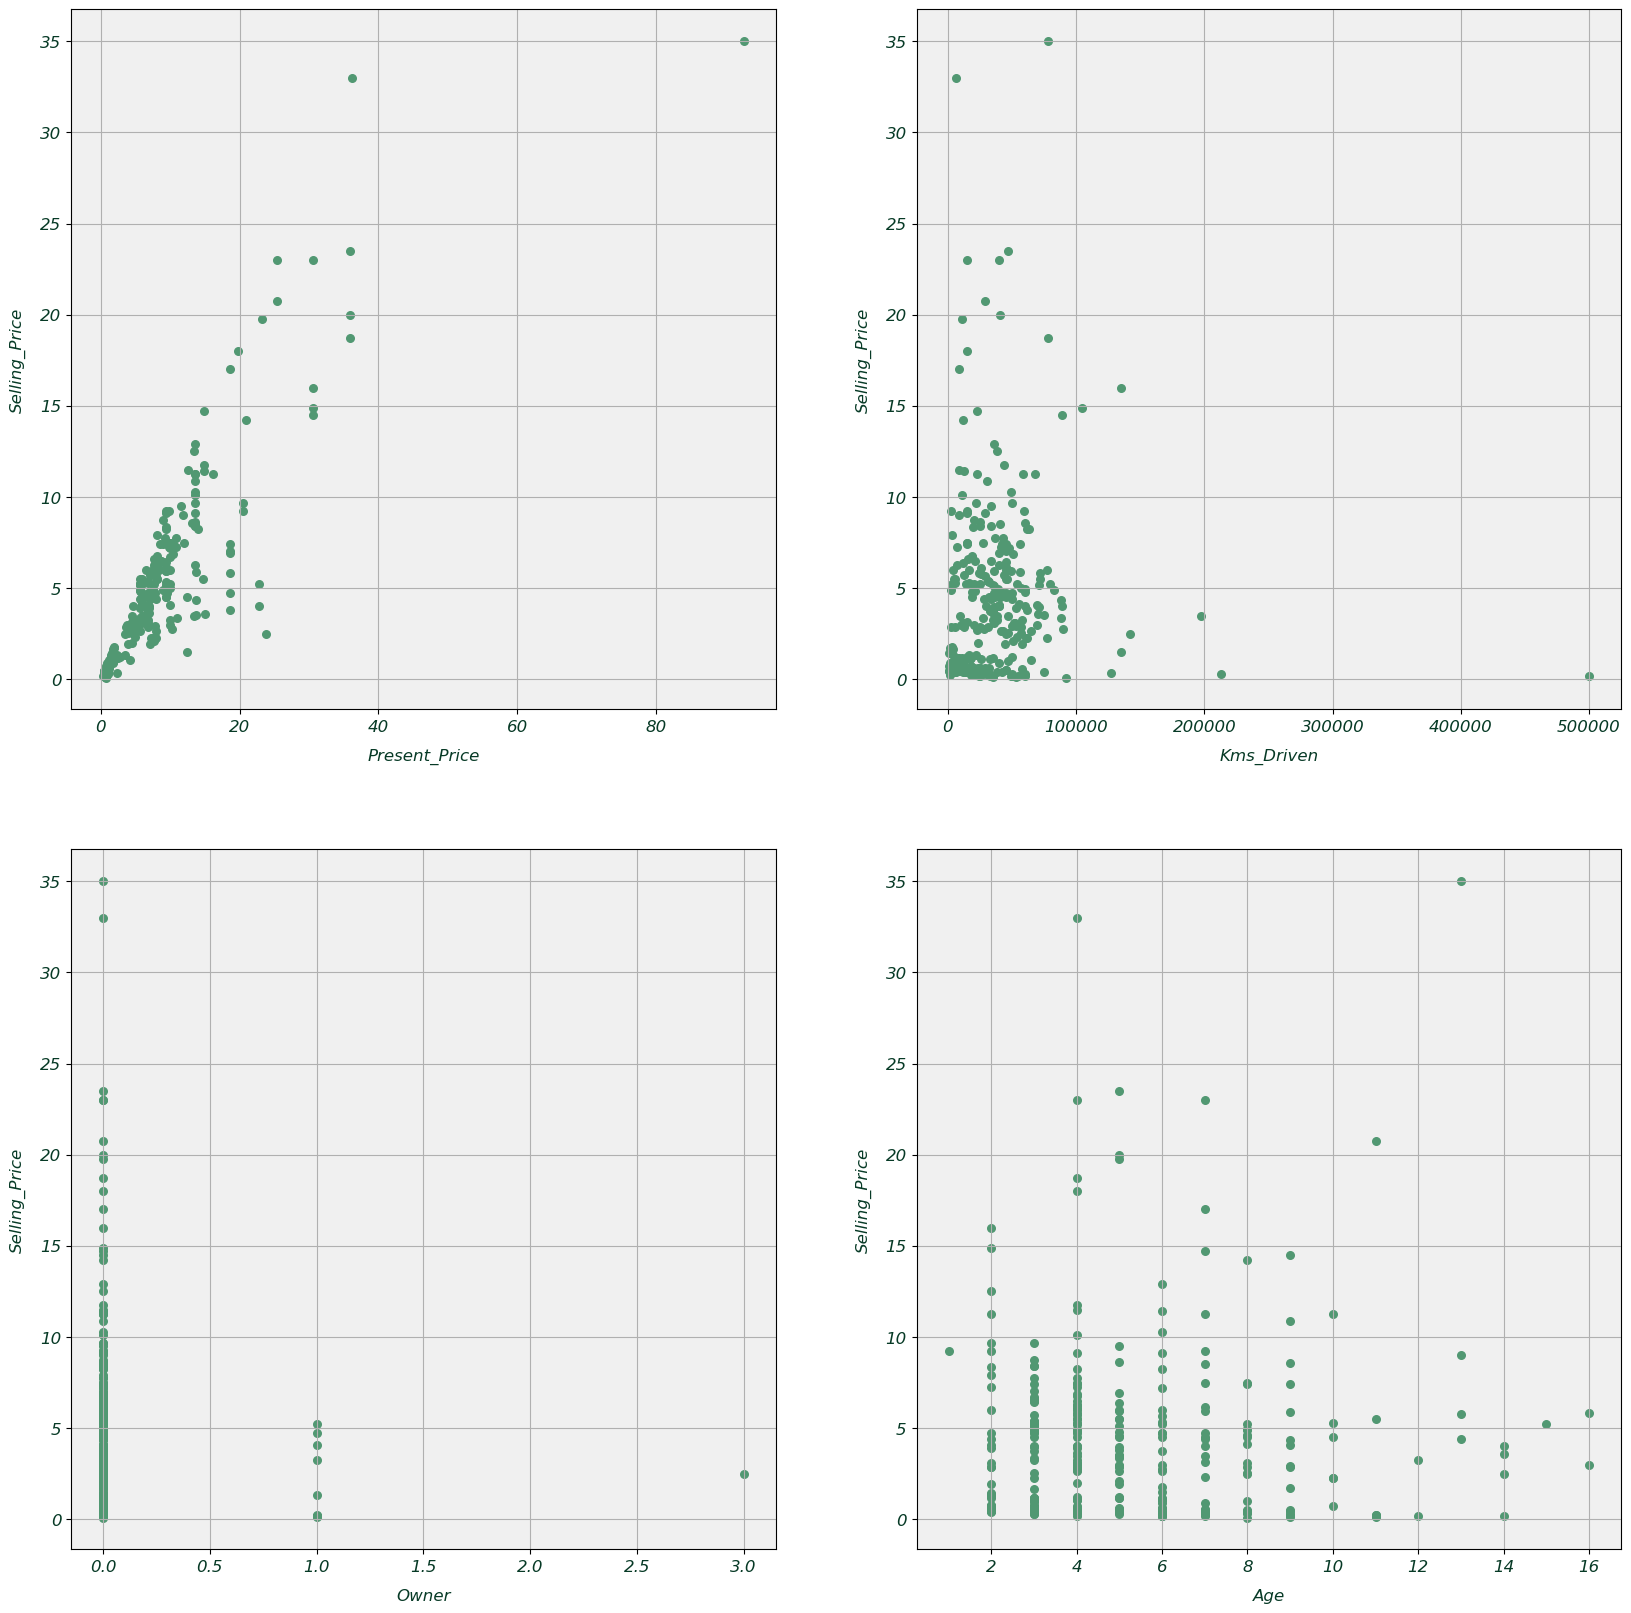

In [185]:
#Ploting numerical features with selling price(Target) :

plt.figure(figsize = (20,20))

#A loop through numerical columns enumerate
for n,col in enumerate(['Present_Price','Kms_Driven','Owner','Age']):
    plt.subplot(2, 2, n+1, facecolor = '#f0f0f0')
    plt.scatter(df2[col] , df2.Selling_Price, c = '#519872' , alpha = 1 , s = 30)
    plt.xlabel(col, color = '#073A26' , fontsize = 12,  fontstyle = "oblique", labelpad=10)
    plt.ylabel('Selling_Price', color = '#073A26' , fontsize = 12,  fontstyle = "oblique", labelpad=10 )
    plt.xticks(color = "#073A26" , fontsize=12 , fontstyle = "oblique")
    plt.yticks(color = "#073A26" , fontsize=12 , fontstyle = "oblique")
    plt.grid()
plt.show() 

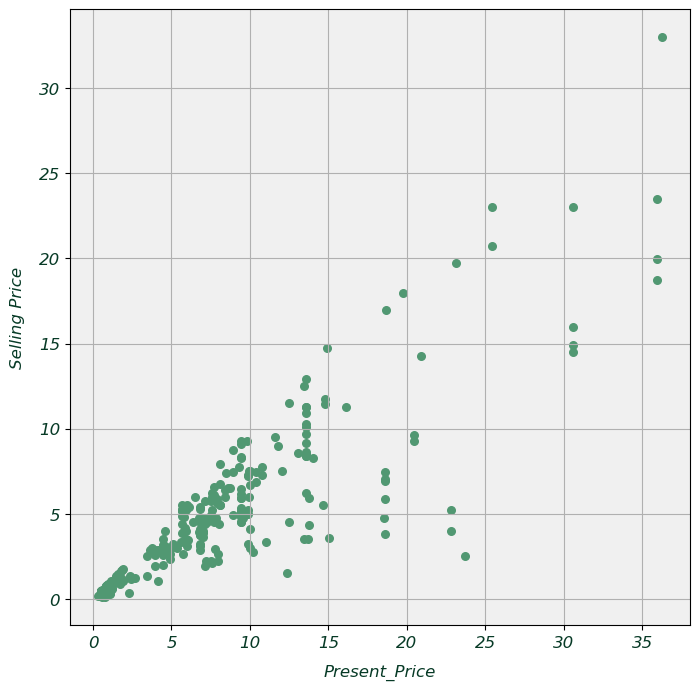

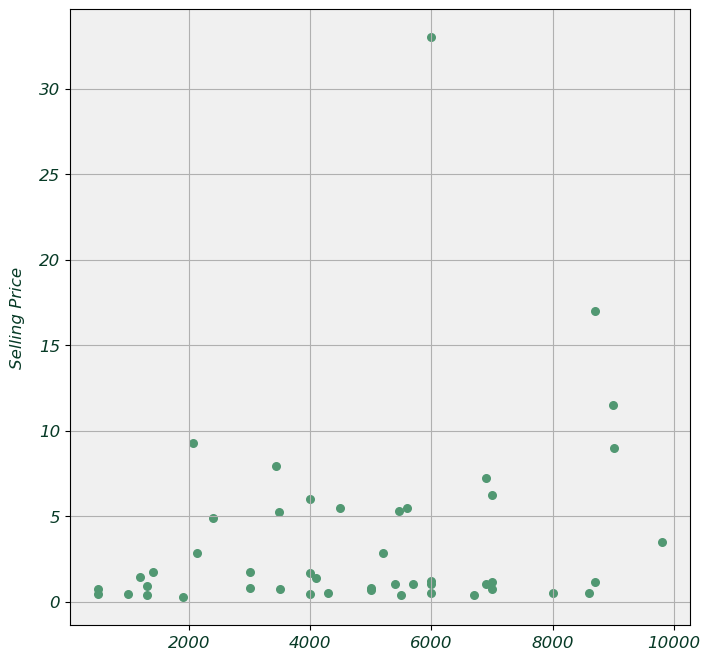

In [186]:
#For a better undrestanding of  the relation between "Present Price" and "KMS Driven" with "Selling Price" :

#Putting aside possible noises
df_present = df2[df2['Present_Price'] < 40]
df_kmsdriven = df2[df2['Kms_Driven'] < 10000 ]

#Plotting "Present Price" with "Selling Price"
plt.figure(figsize = (8,8))
plt.subplot(1,1,1,facecolor = '#f0f0f0')
plt.scatter(df_present['Present_Price'],df_present.Selling_Price, c = '#519872' ,s = 30)
plt.xlabel("Present_Price" , color = "#073A26" , fontsize=12 , fontstyle = "oblique", labelpad=10)
plt.ylabel("Selling Price" , color = "#073A26" , fontsize=12 , fontstyle = "oblique", labelpad=10)
plt.xticks(color = "#073A26" , fontsize=12 , fontstyle = "oblique")
plt.yticks(color = "#073A26" , fontsize=12 , fontstyle = "oblique")
plt.grid()
plt.show()

#Plotting "KMS Driven" with "Selling Price"
plt.figure(figsize = (8,8))
plt.subplot(1,1,1,facecolor = '#f0f0f0')
plt.scatter(df_kmsdriven['Kms_Driven'],df_kmsdriven.Selling_Price, c = '#519872' ,s = 30)
plt.xlabel("" , color = "#073A26" , fontsize=12 , fontstyle = "oblique", labelpad=10)
plt.ylabel("Selling Price" , color = "#073A26" , fontsize=12 , fontstyle = "oblique", labelpad=10)
plt.xticks(color = "#073A26" , fontsize=12 , fontstyle = "oblique")
plt.yticks(color = "#073A26" , fontsize=12 , fontstyle = "oblique")
plt.grid()
plt.show()

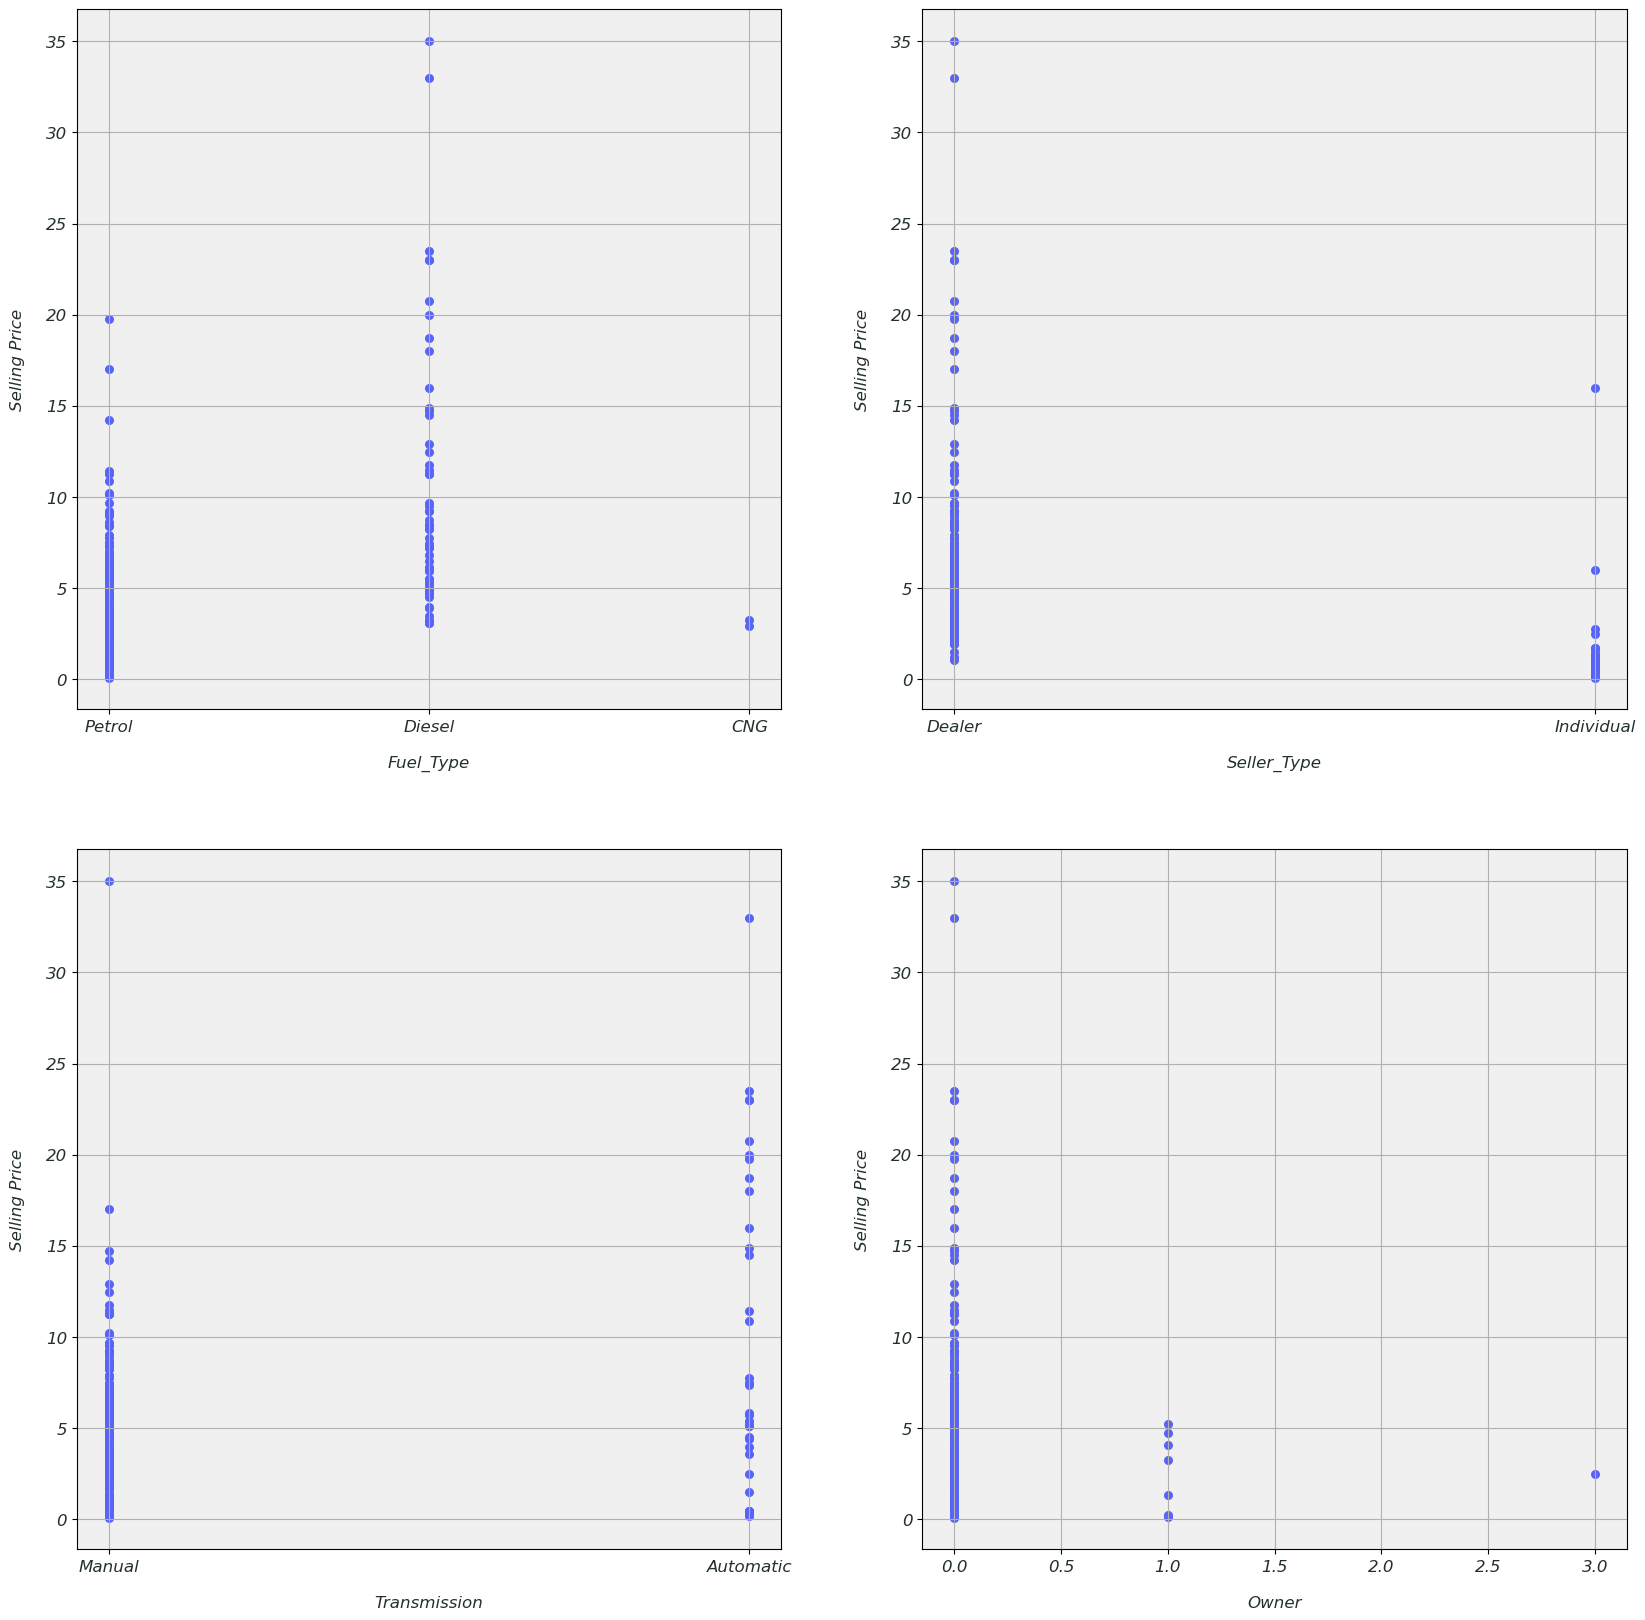

In [187]:
#Ploting categorical features with selling price :

plt.figure(figsize = (20,20))

#A loop through categorical columns
for n,col in enumerate(["Fuel_Type" , "Seller_Type" , "Transmission" , "Owner"]):
    plt.subplot(2, 2, n+1, facecolor = '#f0f0f0')
    plt.scatter(df2[col] , df2.Selling_Price, c = "#5863F8" , alpha = 1 , s = 30)
    plt.xlabel(col , color = "#23302D" , fontsize=12 , fontstyle = "oblique", labelpad=15)
    plt.ylabel("Selling Price" , color = "#23302D" , fontsize=12 , fontstyle = "oblique", labelpad=15)
    plt.yticks(color = "#23302D" , fontsize=12 , fontstyle = "oblique")
    plt.xticks(color = "#23302D" , fontsize=12 , fontstyle = "oblique")
    plt.grid()
plt.show()

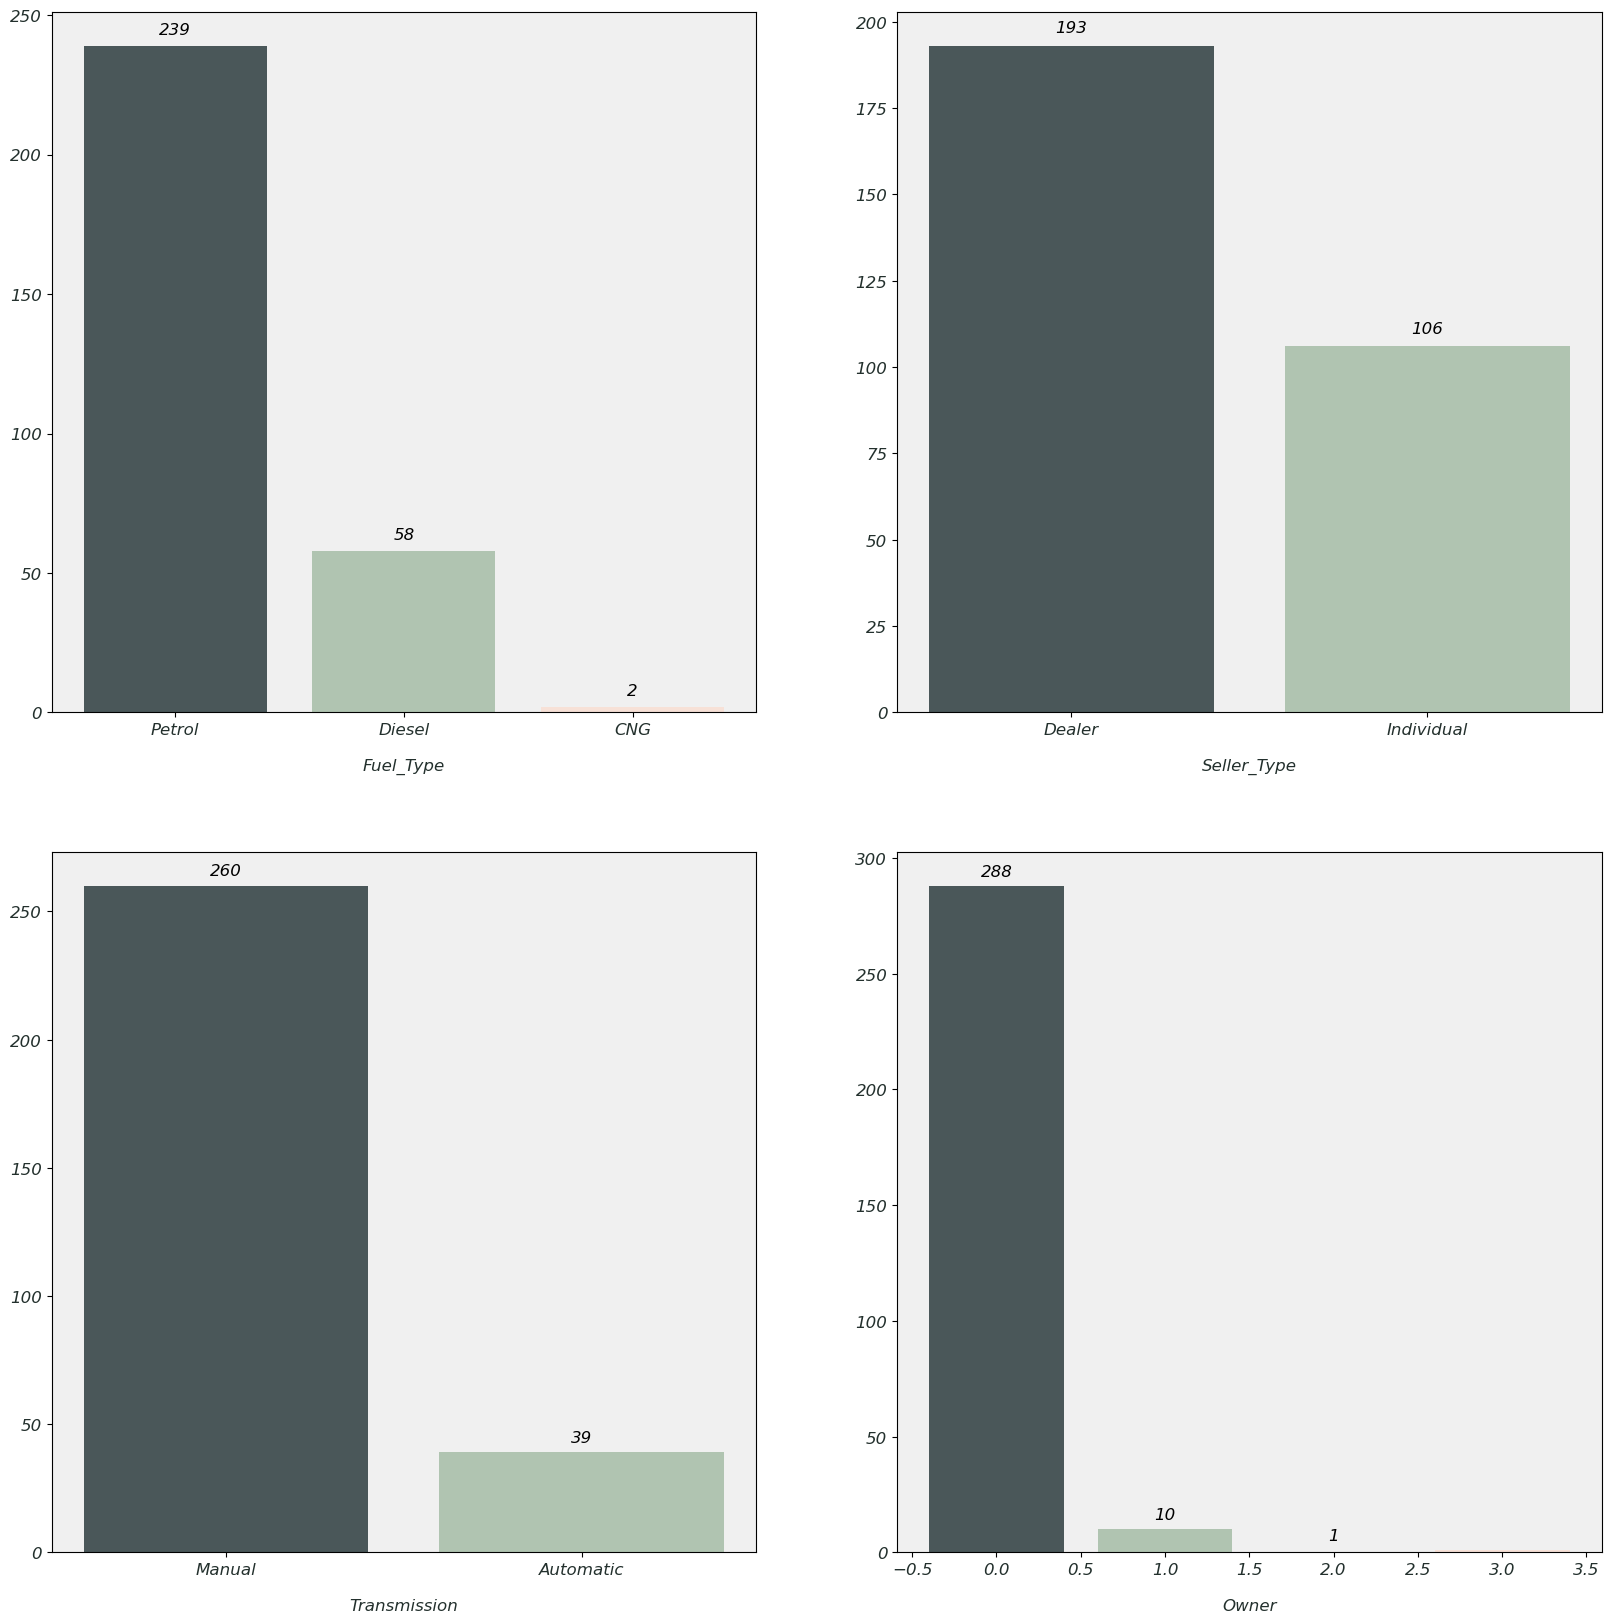

In [188]:
#Comparing the disturbution of values in each categorical column :

plt.figure(figsize=(20,20))
#Plotting count bars
for n,col in enumerate(['Fuel_Type','Seller_Type','Transmission','Owner']):
    count = df2[col].value_counts()
    plt.subplot(2,2,n+1,facecolor = '#f0f0f0')
    plt.bar(count.index,count.values,color= ['#4A5759','#B0C4B1', "#F7E1D7",])

    #Putting the count of each br on its top
    for i,v in enumerate(count):
        plt.text(i,v+3,str(v),ha = 'center', va = 'bottom', fontstyle = 'oblique', fontsize = 12)
    plt.xlabel(col,color = '#23302D',fontsize = 12,fontstyle='oblique',labelpad=15)
    plt.xticks(color = '#23302D',fontsize = 12,fontstyle='oblique')
    plt.yticks(color = '#23302D',fontsize = 12,fontstyle='oblique')
plt.show()
        
    
    

In [189]:
#Labling categorical features :
df3 = df2.copy()
columns = ['Fuel_Type','Seller_Type','Transmission']

# A loop through categorical features
for i in columns :
    temp = LabelEncoder()

    # Encoding them and add up by 2
    df3[i] = temp.fit_transform(df3[i])
    df3[i] = df3[i]+2    

In [190]:
#Removing noises :
df3 = df3[(df3["Selling_Price"]<30) | (df3["Kms_Driven"]<40000)]

In [191]:
df3

,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Age
0,3.35,5.59,27000,4,2,3,0,5
1,4.75,9.54,43000,3,2,3,0,6
2,7.25,9.85,6900,4,2,3,0,2
3,2.85,4.15,5200,4,2,3,0,8
4,4.60,6.87,42450,3,2,3,0,5
...,...,...,...,...,...,...,...,...
294,9.50,11.60,33988,3,2,3,0,5
295,4.00,5.90,60000,4,2,3,0,4
296,3.35,11.00,87934,4,2,3,0,3
297,11.50,12.50,9000,3,2,3,0,4


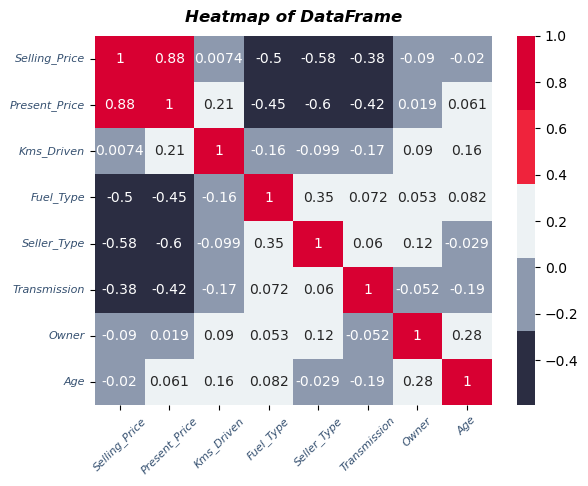

In [192]:
#Correlations between features and target :
df4 = df3.copy()
sns.heatmap(df4.corr(),annot = True , cmap = ['#2b2d42' , '#8d99ae' , '#edf2f4' , '#ef233c' , '#d80032'])
plt.title('Heatmap of DataFrame', fontsize = 12 , fontweight='bold' , fontstyle = 'oblique' , pad = 10 )
plt.yticks(color = "#355070" , fontsize = 8 , fontstyle = "oblique")
plt.xticks(color = "#355070" , fontsize = 8 , fontstyle = "oblique" , rotation = 45)
plt.show()

In [193]:
#Normalizing :

scaler = MinMaxScaler(feature_range = (1,2))
norm = scaler.fit_transform(df4[['Age','Kms_Driven','Fuel_Type','Seller_Type', 'Transmission','Owner','Present_Price']])
norm = pd.DataFrame(norm , columns = ['Age','Kms_Driven','Fuel_Type','Seller_Type', 'Transmission','Owner','Present_Price'] )
norm.describe()

,Age,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Present_Price
count,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000
mean,1.291051,1.072630,1.897651,1.355705,1.869128,1.014541,1.193139
std,0.190815,0.078094,0.210246,0.479532,0.337828,0.083042,0.195356
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,1.133333,1.029029,2.000000,1.000000,2.000000,1.000000,1.024506
50%,1.266667,1.062667,2.000000,1.000000,2.000000,1.000000,1.160262
75%,1.400000,1.096247,2.000000,2.000000,2.000000,1.000000,1.262810
max,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000


In [194]:
# X(Features) and Y(Target) :
x = norm
y = df4.Selling_Price

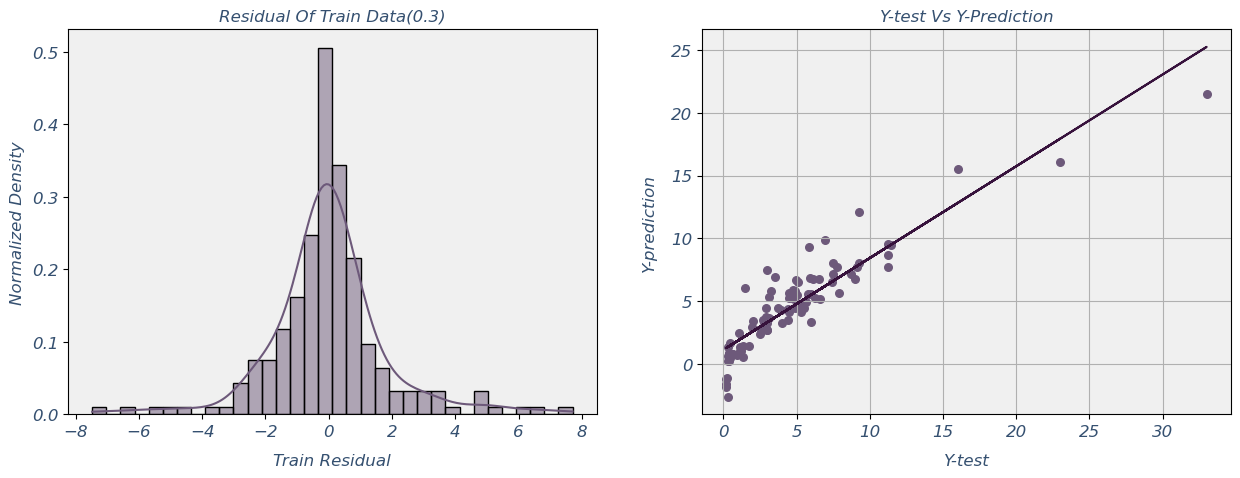

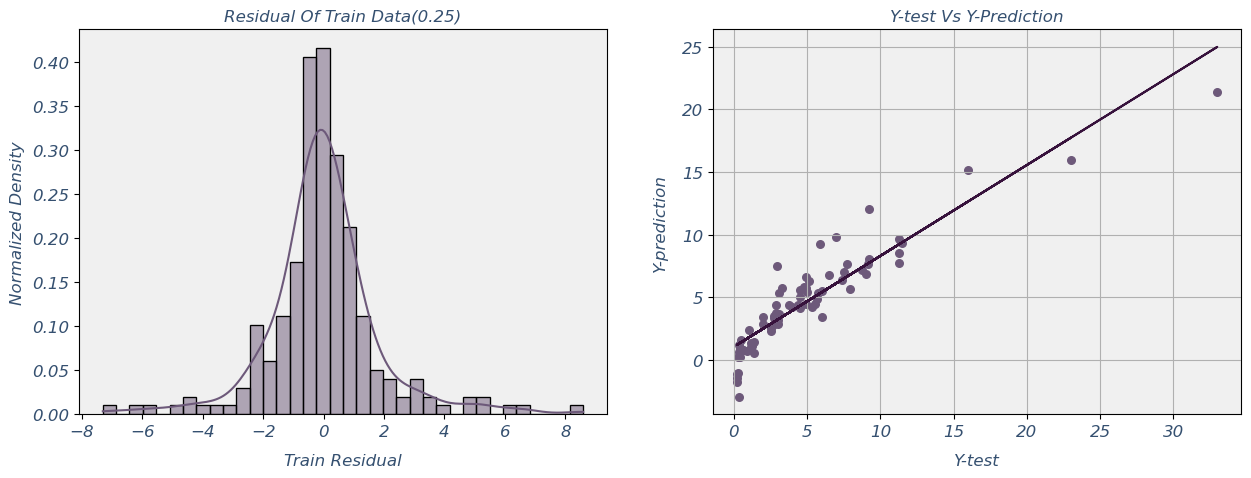

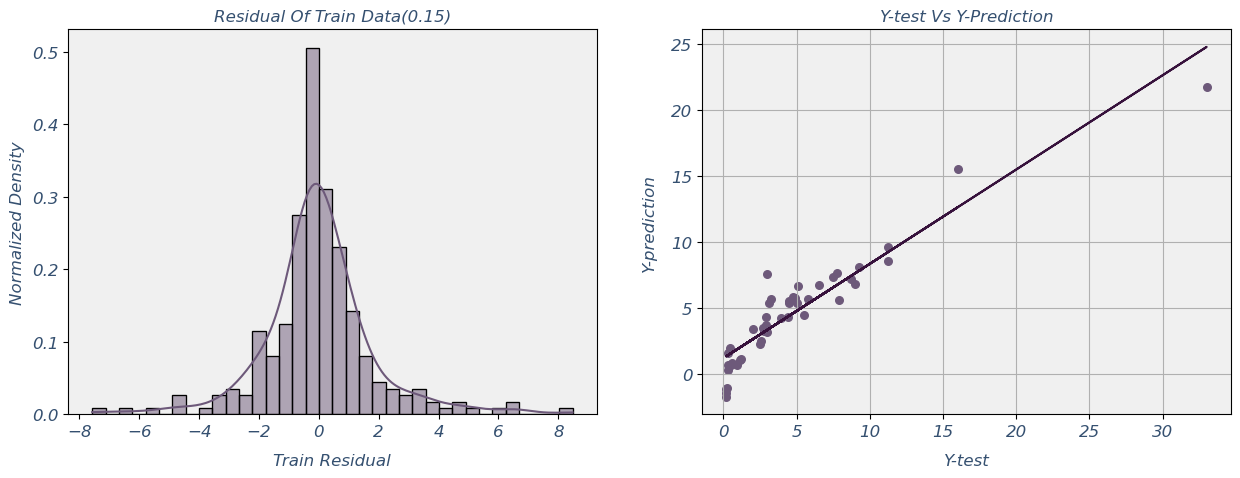

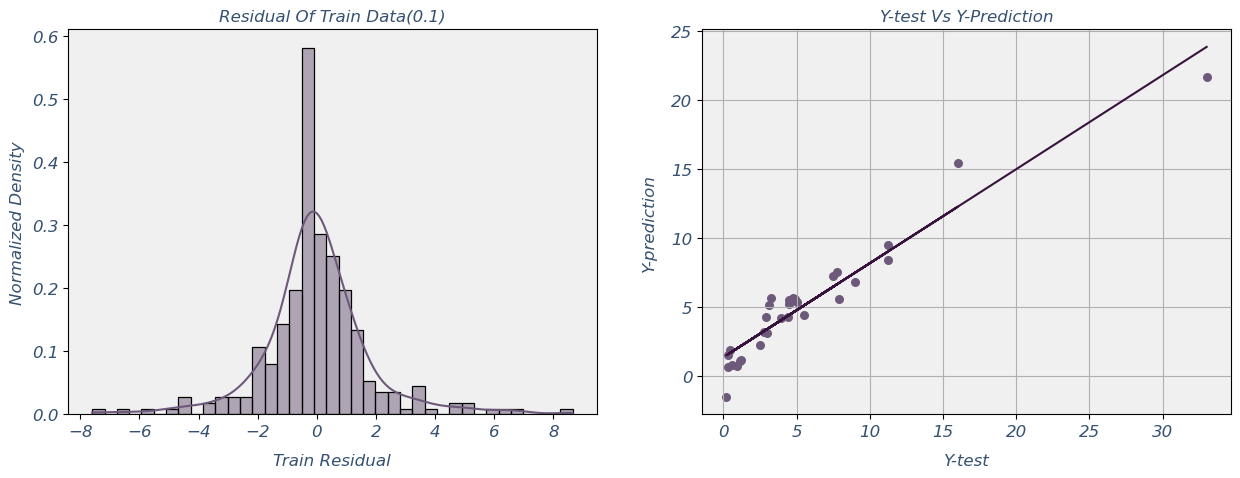

,MAE,MSE,Train R2 Score,Test R2 Score
0.30,1.258194,4.188088,0.831910,0.821412
0.25,1.290913,4.539793,0.826409,0.832478
0.15,1.237204,4.678391,0.825331,0.846783
0.10,1.279821,5.744664,0.823789,0.855865


In [195]:
# Creating a def that fit a linear regression model on a variaty of test sizes and compare the results
def linreg(x,y,testsize):

    # An array to store the evaluations results so at the end convert it to data frame for better presentation
    val = np.ones((len(testsize),4))

     # Creat our regressor
    regressor = LinearRegression()

    # Fit a model and do the evaluations for every test size
    for n, test in enumerate(testsize):

        # Creating our test and train data
        x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = test,random_state = 0)

         # Fitting our model
        regressor.fit(x_train,y_train)

         # Store the value predection of our train and test data
        y_predtest = regressor.predict(x_test)
        y_predtrain = regressor.predict(x_train)

        # Caculating the metrics of Our model 

        # Mean Absolute Error :
        mae = metrics.mean_absolute_error(y_test,y_predtest)
        val[n][0] = mae

        #Mean Squared Error :
        mse = metrics.mean_squared_error(y_test,y_predtest)
        val[n][1] = mse

        # R2 score of train data
        r2_train = metrics.r2_score(y_train,y_predtrain)
        val[n][2] = r2_train

        # R2 score of test data
        r2_test = metrics.r2_score(y_test,y_predtest)
        val[n][3] = r2_test

        # Plotting the histogram of residuals & scatter plot of predection Y and real Y

        #First Plotting the histogram plt.subplot(1,2,2,facecolor = '#f0f0f0') of residuals :
        plt.figure(figsize = (15,5))
        plt.subplot(1,2,1, facecolor = '#f0f0f0')
        sns.histplot((y_train - y_predtrain), kde = True , stat = 'density', color = '#6d597a')
        plt.xlabel('Train Residual', color = '#355070', fontsize = 12, fontstyle= 'oblique', labelpad = 10)
        plt.ylabel('Normalized Density',color ='#355070', fontsize = 12, fontstyle= 'oblique', labelpad = 5)
        plt.title('Residual Of Train Data({})'.format(test)  , color = "#355070" , fontsize=12 , fontstyle = "oblique")
        plt.xticks(color ='#355070' , fontsize= 12, fontstyle = 'oblique')
        plt.yticks(color ='#355070' , fontsize= 12, fontstyle = 'oblique')

        # Now plotting scatter plot between predicted Y and real Y
        plt.subplot(1,2,2,facecolor = '#f0f0f0')
        plt.scatter(y_test, y_predtest , c = '#6d597a', alpha = 1, s = 30)
        # Also fitting a linear regression line on this scatter plot for our better undrestanding
        slope, intercept = np.polyfit(y_test, y_predtest, deg=1)
        plt.plot(y_test, slope*y_test+intercept, color='#37123c', label='Regression Line')
        plt.xlabel('Y-test' , color = '#355070' , fontsize=12 , fontstyle = 'oblique', labelpad=10)
        plt.ylabel('Y-prediction', color = '#355070' , fontsize=12 , fontstyle = 'oblique', labelpad=10)
        plt.title('Y-test Vs Y-Prediction' , color = '#355070' , fontsize=12 , fontstyle = 'oblique')
        plt.xticks(color = '#355070' , fontsize=12 , fontstyle = 'oblique')
        plt.yticks(color = '#355070', fontsize=12, fontstyle= 'oblique')
        plt.grid()
        plt.show()
    # Displayin metrics of each model in a data frame for better comparison
    eva = pd.DataFrame(val , columns = ['MAE' , 'MSE' , 'Train R2 Score' , 'Test R2 Score'] , index = testsize)
    display(eva)

testsize = [0.3, 0.25, 0.15, 0.1]

# Fitting our model with the given test sizes
linreg(x,y,testsize)




In [196]:
# Creating possible polynominal features :

# All possible polynominal features of degree 3
poly = PolynomialFeatures(degree = 3 , include_bias=False)
x_poly = poly.fit_transform(x)

# Creat DataFrame out of it
x_poly = pd.DataFrame(x_poly, columns=poly.get_feature_names_out())

# Adding other possible feature based on our plots
x_poly['Log_Age'] = np.log10(x.Age)
x_poly['Log_Owner'] = np.log10(x.Owner)
x_poly['Log__Kms_Driven'] = np.log10(x.Kms_Driven)

In [197]:
# P-Value and F-Score :

# DataFrame to show P-Value and F-Score of each feature
f_scores , p_values = f_regression(x_poly , y)
df_p_values = pd.DataFrame({'P-Values': p_values, 'F-Scores' : f_scores , 'Feature': x_poly.columns})
df_p_values.set_index('Feature', inplace=True)

# Sort based on P-Values from low to high
df_p_values.sort_values('P-Values', ascending = True , inplace = True)

# Drop already existed columns in model
df_p_values.drop(index = ['Present_Price','Age','Kms_Driven','Fuel_Type','Seller_Type','Transmission','Owner'], inplace=True)

# Removing insignificent features
df_p_values = df_p_values[(df_p_values["P-Values"] < 0.05)]
df_p_values

,P-Values,F-Scores
Feature,,
Present_Price^2,3.548568e-95,965.369735
Present_Price^3,4.046030e-88,834.349534
Kms_Driven Present_Price^2,2.945060e-71,573.847493
Owner Present_Price^2,6.381846e-66,504.674978
Fuel_Type Present_Price^2,2.698733e-57,404.323039
...,...,...
Kms_Driven Transmission Present_Price,1.846861e-04,14.340926
Kms_Driven Seller_Type Present_Price,2.260061e-04,13.942817
Age Transmission Present_Price,1.587941e-03,10.161001


In [198]:
def r2_check(x,y):
    
    # Creat our regressor
    regressor = LinearRegression()
    
        
    # Creating our test and train data
    x_train , x_test , y_train , y_test = train_test_split(x , y , test_size = 0.2 , random_state = 0)
        
    # Fitting our model
    regressor.fit(x_train,y_train)

    # Store the value predection of our train and test data
    y_predtest = regressor.predict(x_test)

    # Caculating the R2 score and returning it 
    r2 = metrics.r2_score(y_test,y_predtest)
    return r2
r2_check(x,y)

0.8447809725525517

In [199]:
# Improving Model :

x_temp = x.copy()

# Our current r2 score
r2 = r2_check(x,y)

# A loop through each feature to check weather it is making our model better or not
for i in df_p_values.index :
    
    # A temporarily model with new feature
    x_temp[i] = x_poly[i]
    r2_new = r2_check(x_temp,y)
    
    #the new score should be higher and also we dont want more than 20 feature to be added
    if r2_new > r2 + 0.005 and n < 20 :
        r2 = r2_new
    
    # If the feature is no good, we drop it
    else :
        x_temp.drop( i , axis=1, inplace=True)

#Adding new Feature to model
x = x_temp.copy()
print(len(x_temp.columns))

13


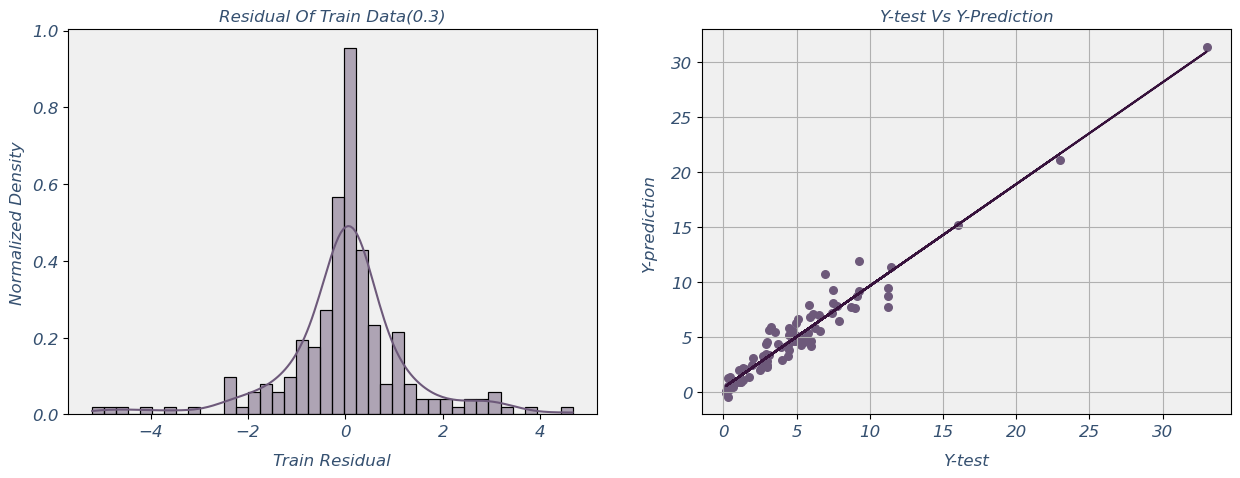

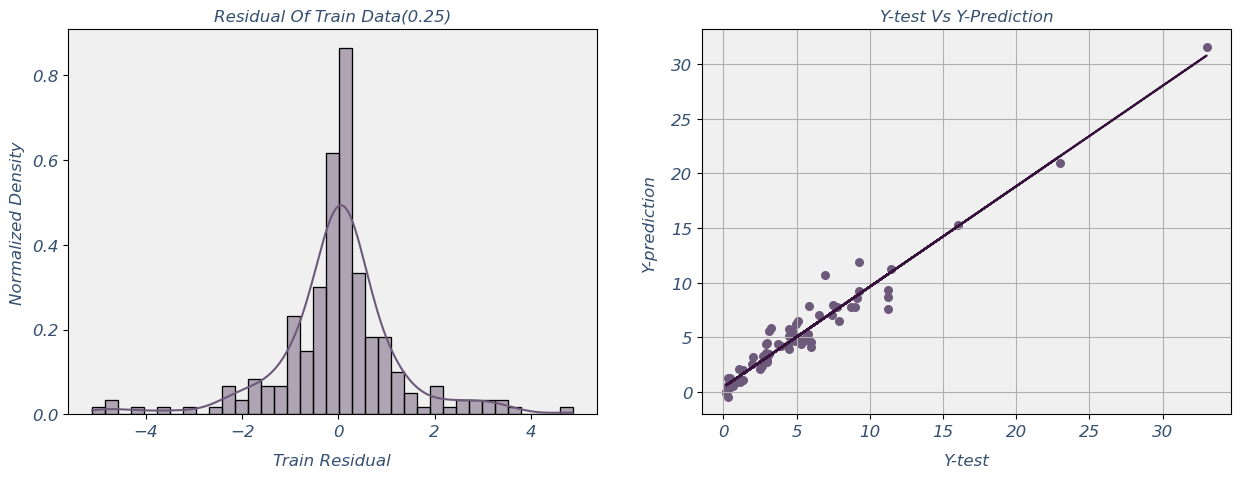

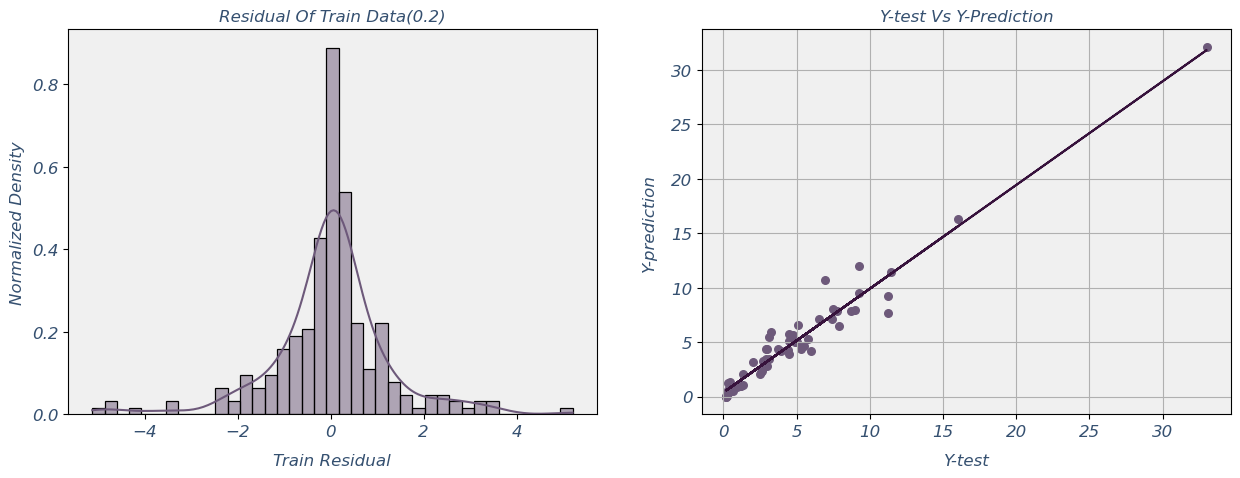

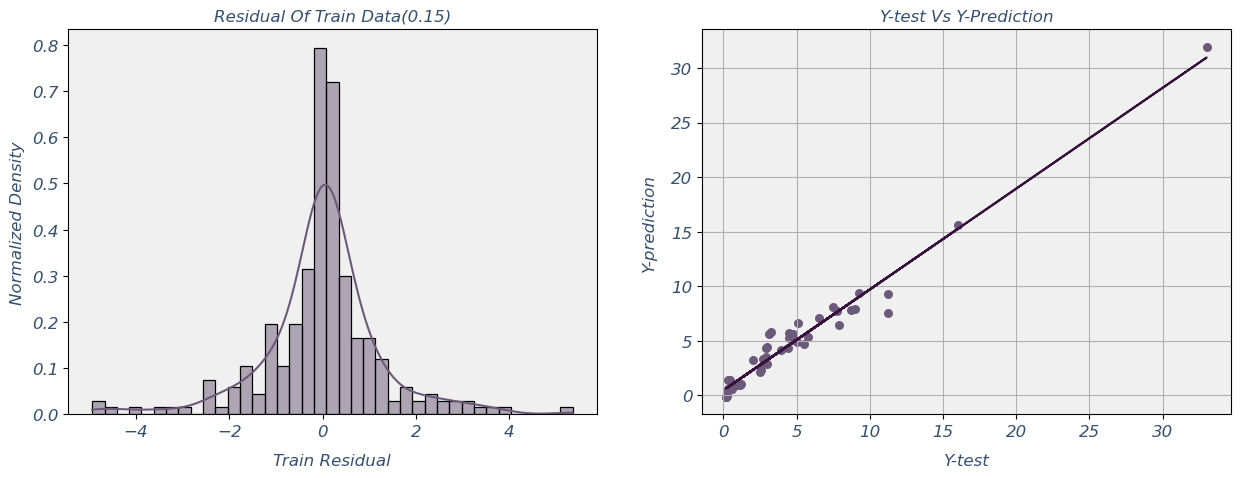

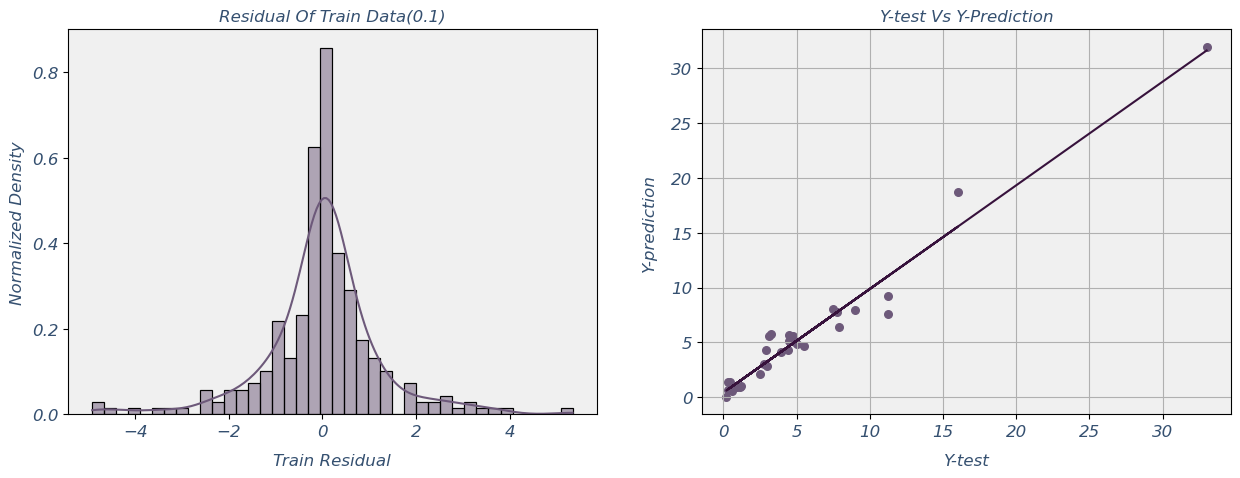

,MAE,MSE,Train R2 Score,Test R2 Score
0.30,0.806006,1.278652,0.919668,0.945476
0.25,0.795427,1.327396,0.918236,0.951018
0.20,0.751448,1.278258,0.922575,0.950143
0.15,0.746305,1.153994,0.919952,0.962207
0.10,0.889177,1.660464,0.920959,0.958339


In [200]:
#Testing new model
testsize = [0.3 , 0.25 , 0.2 , 0.15 , 0.1]

linreg(x,y,testsize)

In [201]:
# Performing crossvalidation with 10 fold :

# Number of folds
kf = KFold(10)

# Creating model
model = LinearRegression()

# Performing cross validation
cross_val = cross_val_score(model, x, y, cv = kf, scoring = 'r2')

# Keeping r2-score of each fold
cross_Val = []
for i in cross_val:
    cross_Val.append(round(i,3))
print(cross_Val)

[0.798, 0.872, 0.911, 0.899, -0.412, -84.611, 0.917, 0.615, 0.788, 0.837]


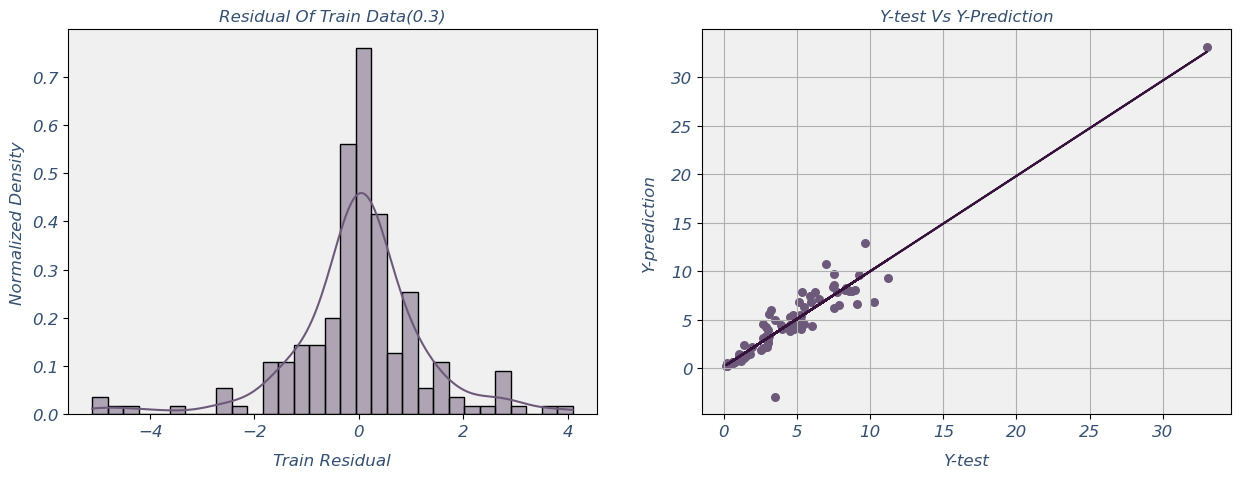

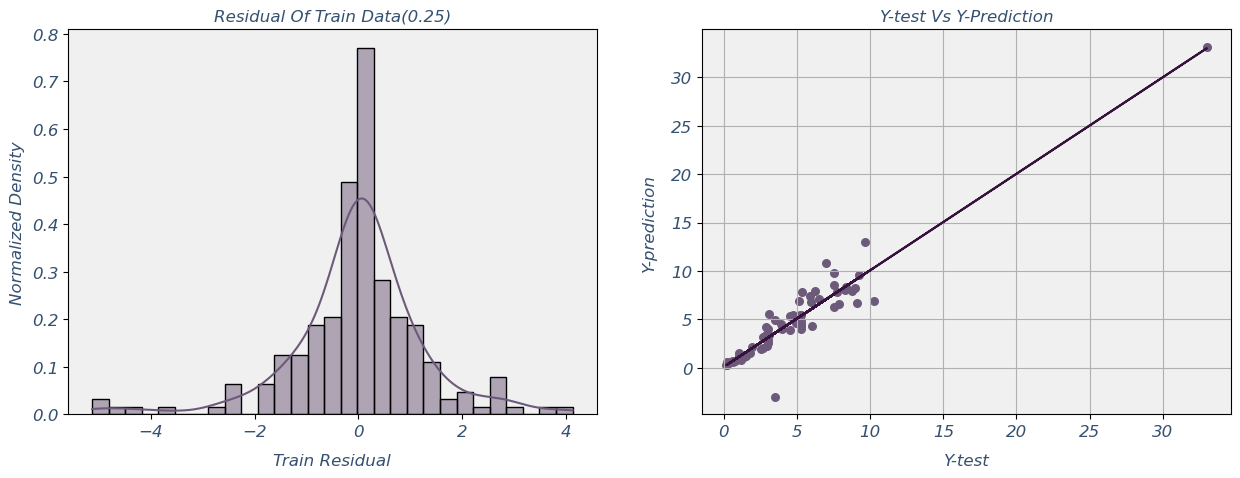

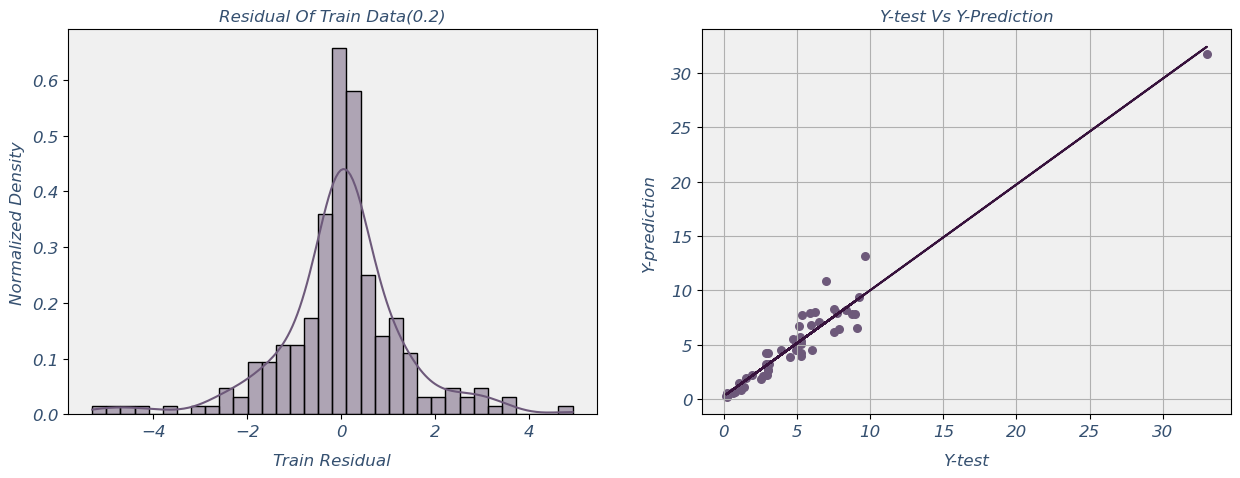

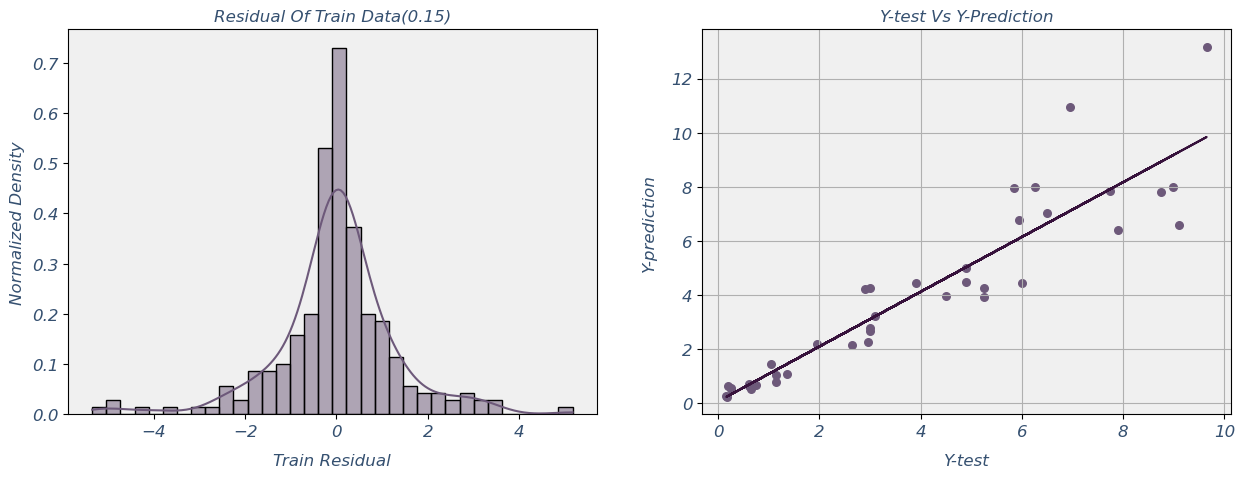

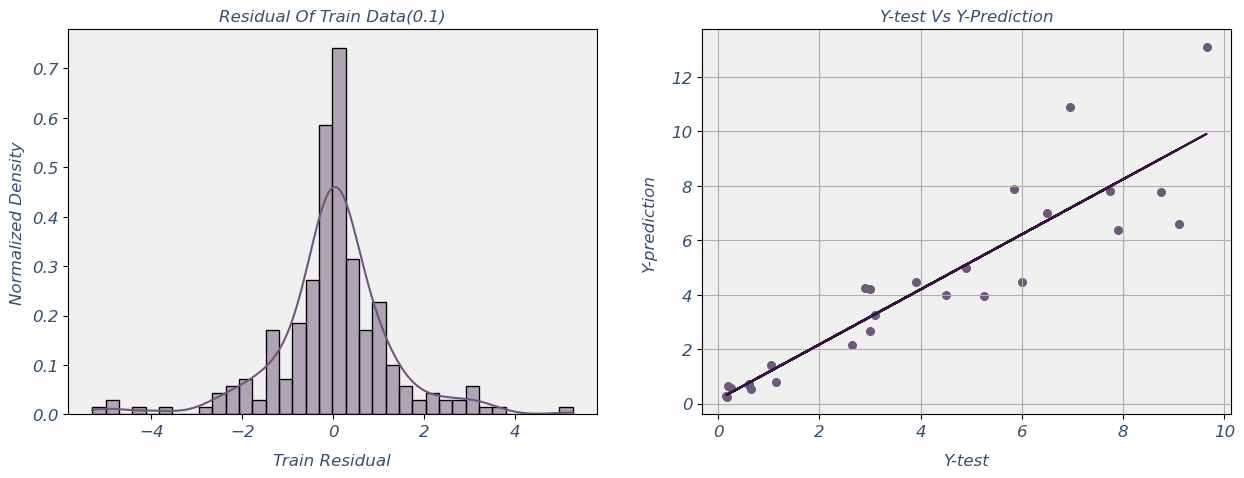

,MAE,MSE,Train R2 Score,Test R2 Score
0.30,0.882638,1.901052,0.929571,0.896953
0.25,0.874908,1.986249,0.927833,0.900919
0.20,0.785987,1.327861,0.916900,0.942526
0.15,0.791075,1.454890,0.927417,0.829244
0.10,0.908335,1.865394,0.927948,0.798167


In [202]:
# Deleting the fold with bad score to see if it improves r2-score 

x_new = x[(x.index < 148) | (x.index > 179)]
y_new = y[(y.index < 148) |  (y.index > 179)]
x.reset_index(drop = True, inplace = True)
y.reset_index(drop = True, inplace = True)

linreg(x_new, y_new, testsize)

In [203]:
# Fiting our final model :

df4 = x.copy()
regressor = LinearRegression()
regressor.fit(x,y)
final = regressor.predict(df4)

In [204]:
# A data frame withe actual and oredicted sellinng price :

df4.insert(0,"Selling_Price",y)
df4.insert(0,"y",final)
df4.sort_values(by = "Present_Price")

,y,Selling_Price,Age,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Present_Price,Present_Price^3,Owner Present_Price^2,Age Present_Price^2,Kms_Driven Present_Price,Fuel_Type^2 Seller_Type,Age Fuel_Type^2
192,0.198633,0.18,1.333333,1.069069,2.0,2.0,2.0,1.0,1.000000,1.000000,1.000000,1.333333,1.069069,8.00,5.333333
180,0.283073,0.27,1.133333,1.041041,2.0,2.0,2.0,1.0,1.004177,1.012584,1.008372,1.142821,1.045390,8.00,4.533333
178,0.273998,0.30,1.533333,1.099099,2.0,2.0,2.0,1.0,1.004456,1.013426,1.008931,1.547028,1.103996,8.00,6.133333
170,1.173376,0.40,1.200000,1.001602,2.0,2.0,1.0,1.0,1.005291,1.015957,1.010610,1.212732,1.006901,8.00,4.800000
184,0.346533,0.25,1.666667,1.063063,2.0,2.0,2.0,1.0,1.005291,1.015957,1.010610,1.684350,1.068688,8.00,6.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50,20.855604,23.00,1.400000,1.079079,1.5,1.0,1.0,1.0,1.843498,6.265096,3.398484,4.757877,1.989280,2.25,3.150000
62,23.724823,23.50,1.266667,1.093093,1.5,1.0,1.0,1.0,1.992481,7.910113,3.969981,5.028643,2.177967,2.25,2.850000
58,24.902807,19.99,1.266667,1.081081,1.5,1.0,1.0,1.0,1.992481,7.910113,3.969981,5.028643,2.154034,2.25,2.850000
61,17.890629,18.75,1.200000,1.155155,1.5,1.0,1.0,1.0,1.992481,7.910113,3.969981,4.763978,2.301625,2.25,2.700000


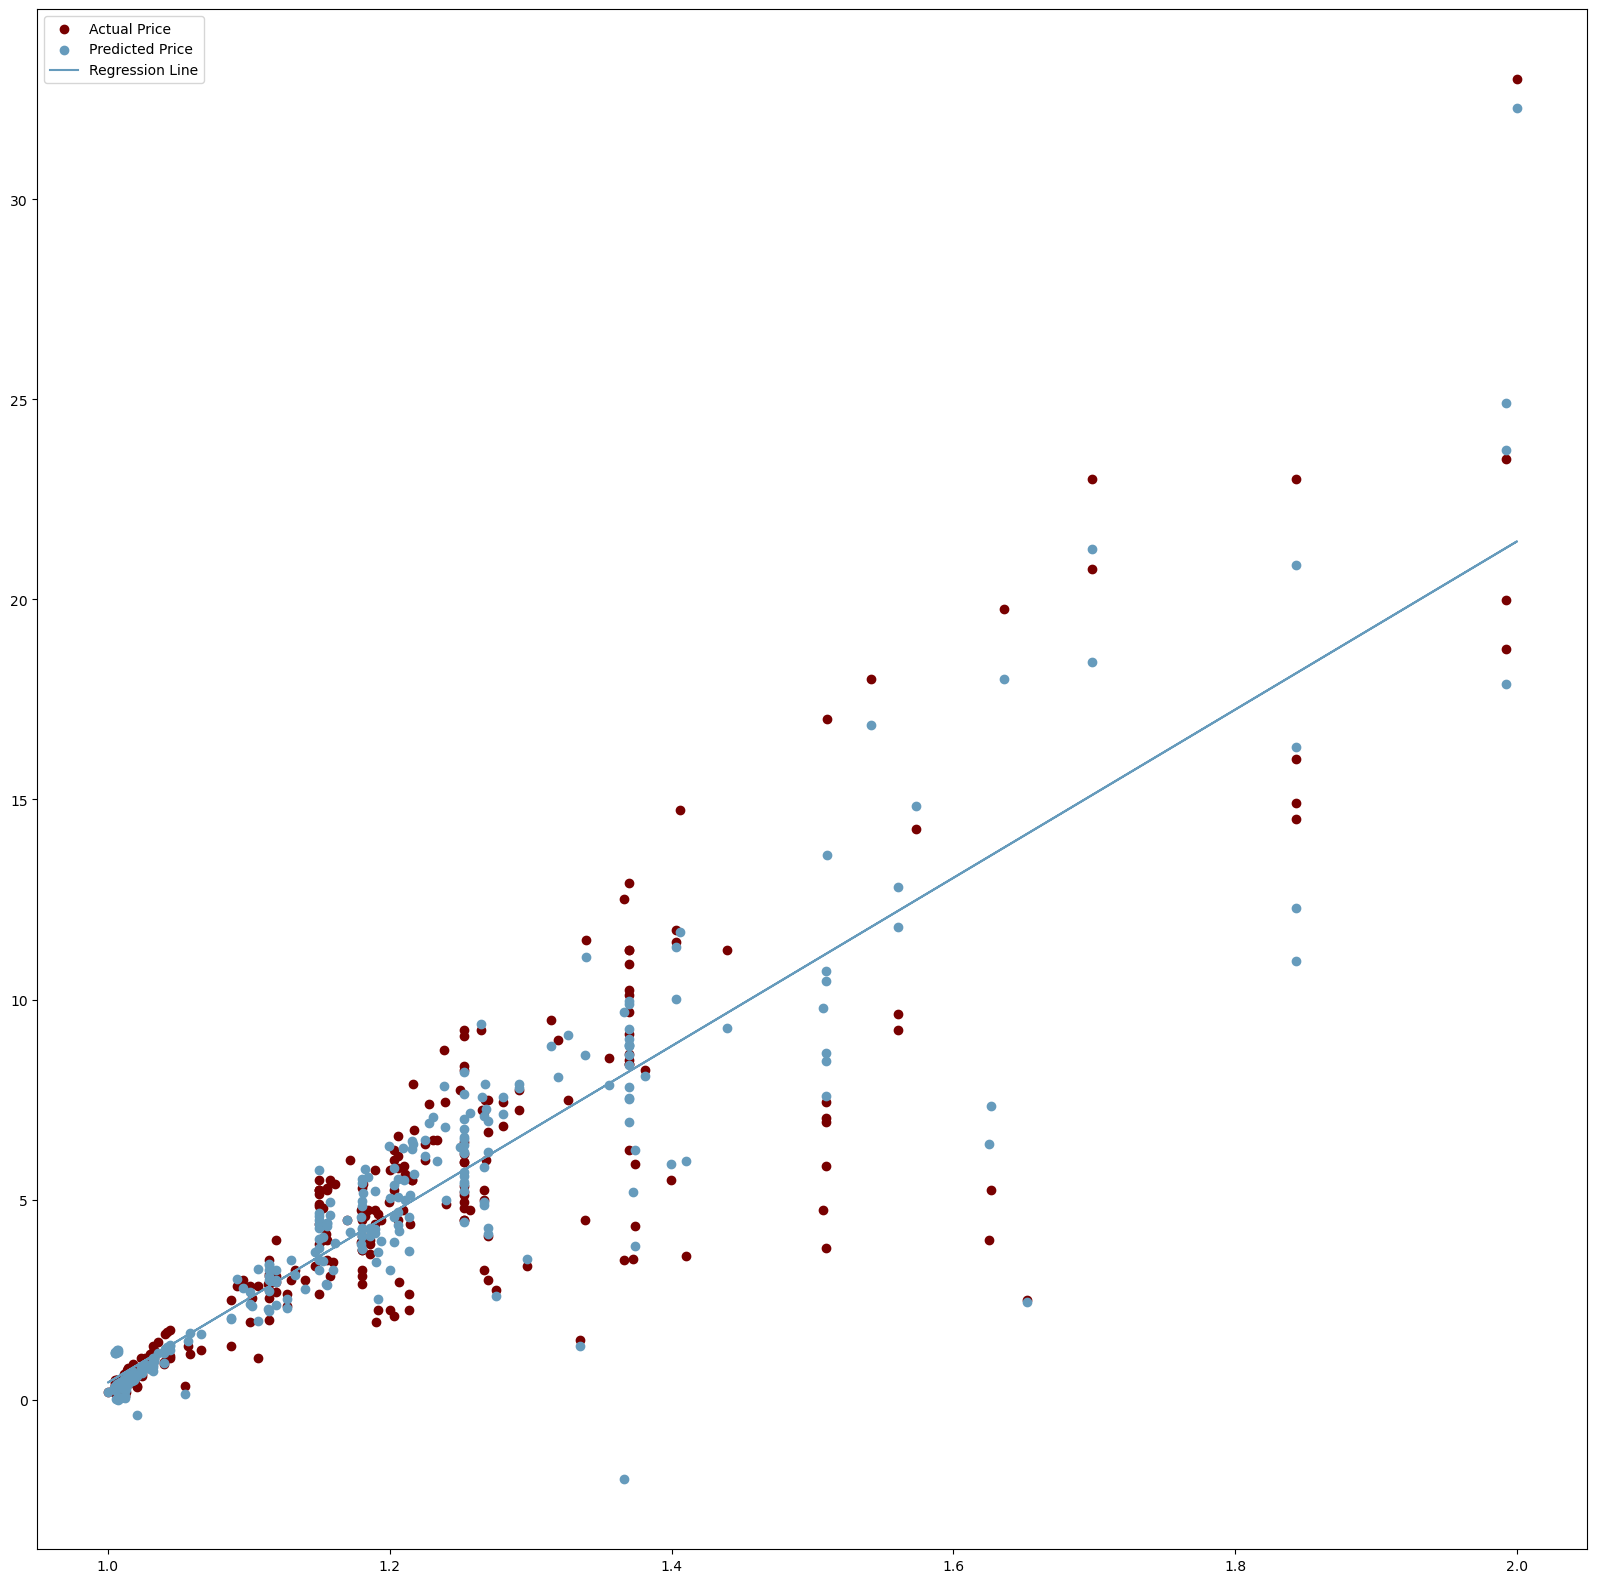

In [205]:
# Creating a scatter to plot actual and predicted selling price :

plt.figure(figsize = (20,20))
plt.scatter(df4.Present_Price, df4.Selling_Price, color = '#780000', label='Actual Price')
plt.scatter(df4.Present_Price,df4.y , color = "#669bbc" , label='Predicted Price')
slope, intercept = np.polyfit(df4.Present_Price, df4.y, deg= 1)
plt.plot(df4.Present_Price,  slope * df4.Present_Price + intercept, color='#669bbc', label='Regression Line')
plt.legend()
plt.show()

In [206]:
# Columns of our final model
x.columns

Index(['Age', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission',
       'Owner', 'Present_Price', 'Present_Price^3', 'Owner Present_Price^2',
       'Age Present_Price^2', 'Kms_Driven Present_Price',
       'Fuel_Type^2 Seller_Type', 'Age Fuel_Type^2'],
      dtype='object')

In [207]:
# Testing our model by an unseen data :

# Unseen Data
Age = 10
Kms_Driven = 42000
Fuel_Type = 4 #Petrol
Seller_Type =  2 #Dealer
Transmission = 3 #Manual
Owner = 1
Present_Price = 11

# Creating a dataframe from unseen data with our initial features 
initial_model = pd.DataFrame({'Age' : [Age] ,
                           'Kms_Driven' : [Kms_Driven],
                           'Fuel_Type' : [Fuel_Type] ,
                           'Seller_Type' : [Seller_Type] ,
                           'Transmission' : [Transmission] ,
                           'Owner' : [Owner] ,
                           'Present_Price' : [Present_Price]})

columns = ['Age' , 'Kms_Driven', 'Fuel_Type','Seller_Type','Transmission' , 'Owner' , 'Present_Price']

# Normalizing unseen data for prediction
norm_initial = pd.DataFrame(scaler.transform(initial_model) , columns = columns)


# Getting values of each feature

Age = norm_initial.Age[0]
Kms_Driven = norm_initial.Kms_Driven[0]
Fuel_Type = norm_initial.Fuel_Type[0]
Seller_Type = norm_initial['Seller_Type'].values[0]
Transmission = norm_initial["Transmission"].values[0]
Owner = norm_initial["Owner"].values[0]
Present_Price = norm_initial['Present_Price'].values[0]


# Creating unseen data frame with all 13 feature  
model_input = pd.DataFrame({'Age' : [Age] ,
                           'Kms_Driven' : [Kms_Driven],
                           'Fuel_Type' : [Fuel_Type] ,
                           'Seller_Type' : [Seller_Type] ,
                           'Transmission' : [Transmission] ,
                           'Owner' : [Owner] ,
                           'Present_Price' : [Present_Price],
                           'Present_Price^3' : [Present_Price**3],
                           'Owner Present_Price^2' : [Owner * (Present_Price**2)],
                           'Age Present_Price^2' : [(Age)* (Present_Price**2)] ,
                           'Kms_Driven Present_Price' : [Kms_Driven * Present_Price] ,
                           'Fuel_Type^2 Seller_Type' : [(Fuel_Type**2) * (Seller_Type)],
                           'Age Fuel_Type^2' : [(Fuel_Type**2) * (Age)],})

#Add unseen data to predict selling price
final = pd.concat([x, model_input], ignore_index = False)
final.reset_index(inplace = True)

regressor = LinearRegression()
regressor.fit(final[:len(final)-1],y)
z = regressor.predict(final[len(final)-1:])
print(f"The predicted selling price is : {z}")

The predicted selling price is : [5.54021576]
